In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.optimize import brentq  # For robust root-finding
from scipy.stats import norm


import sys 
sys.path.append('../')
from bin.dbm import DBManager
from bin.main import Manager 
from bin.options.bsm.bs import bs_df
from models.densityEstimation.iter1.curve_fitting import bspline, smoothing_spline
from anderson_huge import agg_by_strike, get_front_month_chain, andreasen_huge_fit, ah_fit_vega, andreasen_huge_fit_exposure, filter_otm_options
from hc3 import agg_by_strike

2026-02-26 21:59:32 - INFO - Loaded 19 database connections from environment
2026-02-26 21:59:32 - ERROR - Ticker file not found: data/stocks/tickers.json
2026-02-26 21:59:32 - WARNING - Failed to load tickers: [Errno 2] No such file or directory: 'data/stocks/tickers.json'


In [2]:
dbm = DBManager().for_notebook()
manager = Manager(dbm = dbm)
stock = manager.get_stock_data('spy')
price_data = stock.price_data.daily_df
# option_chain =  stock.options.option_chain_on(chain_date = '2026-02-20', use_cache = False)
option_chain = stock.options.chain_df
otm_chain = filter_otm_options(option_chain)


2026-02-26 21:59:34 - INFO - Loaded 19 database connections from environment
2026-02-26 21:59:34 - ERROR - Ticker file not found: data/stocks/tickers.json
2026-02-26 21:59:34 - WARNING - Failed to load tickers: [Errno 2] No such file or directory: 'data/stocks/tickers.json'
2026-02-26 21:59:34 - INFO - All connections cleared
2026-02-26 21:59:34 - INFO - Resolved 18 relative paths to absolute paths for project root: /Users/jerald/Documents/Dir/Python/Stocks
2026-02-26 21:59:34 - INFO - Loaded 19 database connections from environment


In [3]:
# call_option_chain = option_chain[option_chain['type'] == 'Call']
# Fill values for time value which are 0, time value 
oc_bs = bs_df(otm_chain, fit_iv = False)
gatherdates = sorted(oc_bs.gatherdate.unique())
oc_bs = oc_bs[oc_bs.gatherdate == gatherdates[-2]]
front_month = get_front_month_chain(oc_bs, expiry = 1)
gcdf = agg_by_strike(front_month)
gcdf

Using expiry at index 1: 2026-02-27 00:00:00


,timevalue,strike,gexp,cexp,vexp,vega,impliedvolatility,volume,openinterest,oi_chg,lastprice,fairvalue,stk_price
0,0.003642,673.0,-3.803282e+07,-1036.300599,-8336.566270,0.052533,0.24206,10882,6382.0,1374.0,0.17,0.285938,687.89
1,0.003642,674.0,-1.758579e+07,-482.329019,-3594.490135,0.058123,0.23642,10739,2605.0,-78.0,0.21,0.325966,687.89
2,0.003642,675.0,-1.990074e+08,-5462.390933,-37737.895099,0.063739,0.22973,23879,26121.0,-5611.0,0.23,0.365906,687.89
3,0.003642,676.0,-6.141054e+07,-1698.586251,-10739.355063,0.070340,0.22378,7357,7115.0,174.0,0.28,0.417529,687.89
4,0.003642,677.0,-4.944174e+07,-1384.386838,-7917.762234,0.077760,0.21818,10392,5052.0,339.0,0.33,0.480669,687.89
5,0.003642,678.0,-4.714561e+07,-1354.780217,-6855.784386,0.086623,0.21412,14170,4244.0,-56.0,0.39,0.568125,687.89
6,0.003642,679.0,-1.231698e+08,-3588.009871,-16101.756265,0.095005,0.20799,13960,9820.0,990.0,0.46,0.651717,687.89
7,0.003642,680.0,-7.605216e+08,-22845.444881,-88255.017531,0.104837,0.20374,53581,53825.0,13927.0,0.56,0.769656,687.89
8,0.003642,681.0,-1.594127e+08,-4914.939793,-16163.155008,0.114498,0.19835,14410,10057.0,-551.0,0.69,0.895753,687.89
9,0.003642,682.0,-1.383726e+08,-4420.881723,-12004.367336,0.124625,0.19367,20266,7831.0,940.0,0.82,1.053123,687.89


In [4]:
S0 = option_chain.stk_price.iloc[-1]
tau = gcdf['timevalue'].mean()
r = 0.0405
q = 0.00
strikes = gcdf['strike'].values
market_prices = gcdf['lastprice'].values
actual_ivs = gcdf['impliedvolatility'].values
gamma_exposure = gcdf['gexp'].values
charm_exposure = gcdf['cexp'].values
bs_model_prices = gcdf['fairvalue'].values

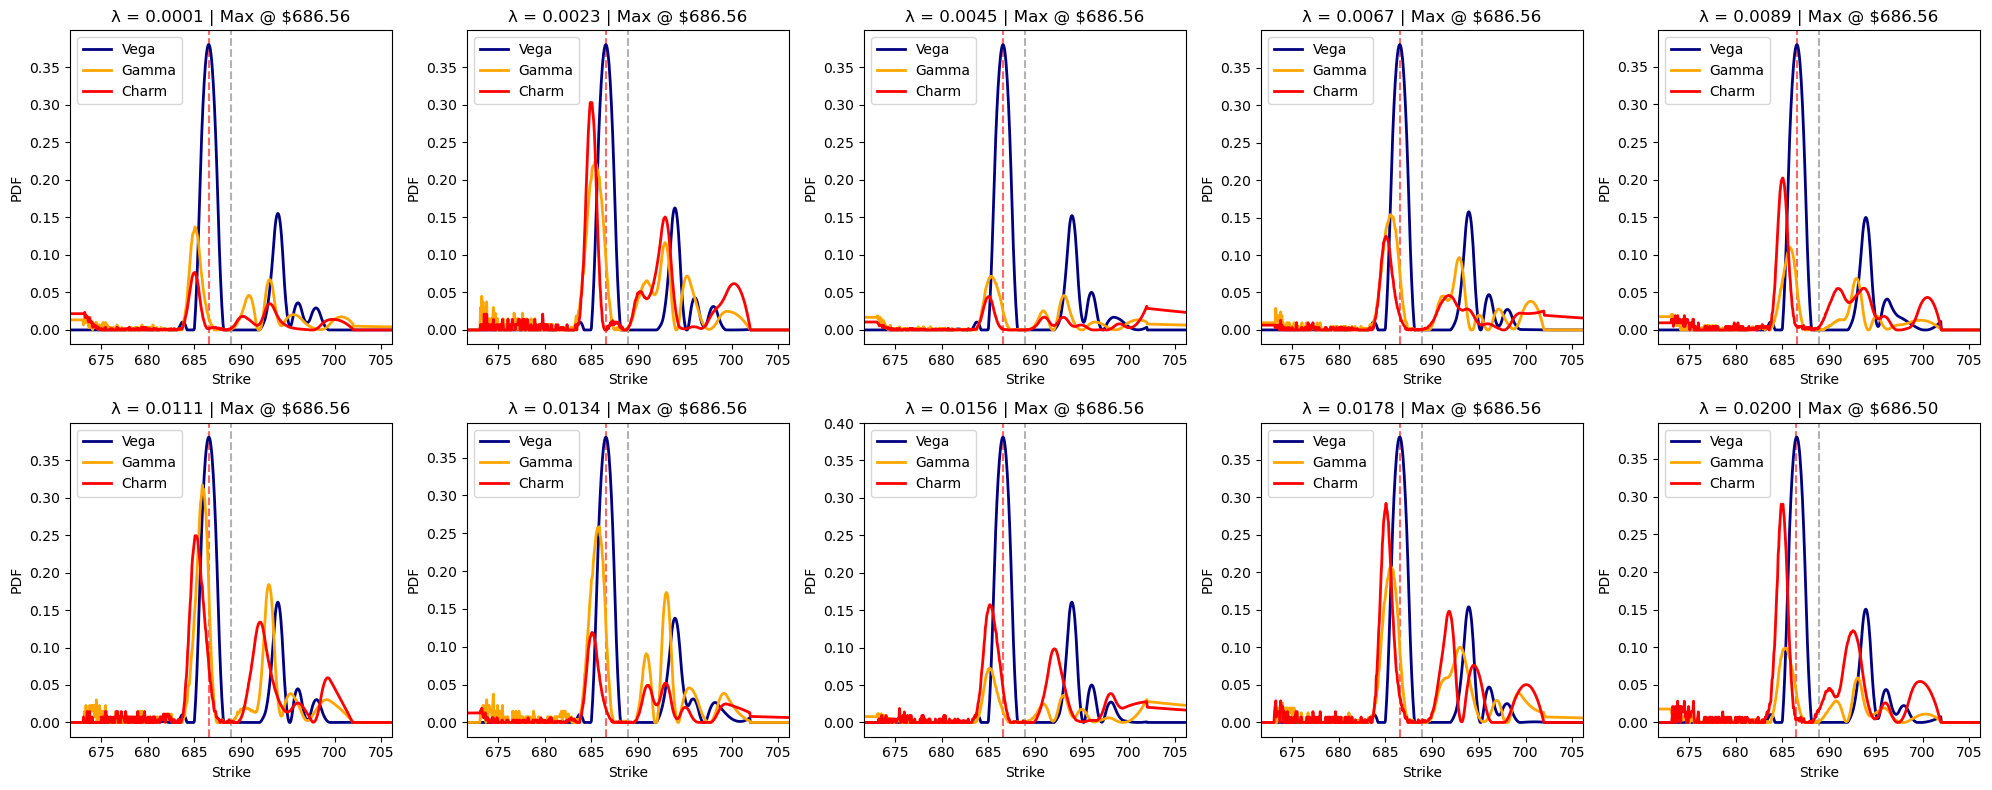

In [5]:
from validate import score_pdf_quality
lambda_penalty_tune = np.linspace(7.5e-5, 2e-2, 10)
n_lam = len(lambda_penalty_tune)
n_cols = 5
n_rows = (n_lam + n_cols - 1) // n_cols


summary_stats = {}
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.atleast_2d(axes)
for i, l in enumerate(lambda_penalty_tune):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]

    fitted_spline, K_fine, pdf, fitted_prices = andreasen_huge_fit(
        strikes, market_prices, S0, r, tau,
        lambda_penalty=l,
        max_iter=10000,
    )

    # Max probability 
    max_prob = np.max(pdf)
    max_prob_idx = np.argmax(pdf)
    max_prob_strike = K_fine[max_prob_idx]
    # Red Vertical Line
    ax.axvline(max_prob_strike, color='red', ls='--', alpha=0.6)


    skew = (max_prob_strike - S0) / (S0 * tau)
    kurtosis = (pdf[max_prob_idx - 1] - 2 * pdf[max_prob_idx] + pdf[max_prob_idx + 1]) / (tau ** 2)
    score, diag = score_pdf_quality(K_fine, pdf, S0, verbose=False)

    summary_stats[l] = {
        'lambda': l,
        'score': score,
        'mode': diag.get('mode', np.nan),
        'skew': diag.get('skew', np.nan),
        'kurt': diag.get('kurt', np.nan),
        'peak_count': diag.get('peak_count', 0),
        'fit_ks': diag.get('fit_ks_penalty', 1.0),
        **diag
    }

    ax.plot(K_fine, pdf, color='navy', lw=2, label = 'Vega')
    ax.axvline(S0, color='gray', ls='--', alpha=0.6)
    ax.set_xlabel("Strike")
    ax.set_ylabel("PDF")
    ax.set_title(f"λ = {l:.4f} | Max @ ${max_prob_strike:.2f}")


    # Now in orange: 
    fitted_spline, K_fine, pdf, fitted_prices, weights = andreasen_huge_fit_exposure(
        strikes, 
        market_prices, 
        S0, 
        r, 
        tau,
        lambda_penalty=l,
        max_iter=10000, 
        weight_type='gamma', 
        exposure_charm=charm_exposure,
        exposure_gamma=gamma_exposure
    )
    ax.plot(K_fine, pdf, color='orange', lw=2, label = 'Gamma')

    # Purple - Charm Exposure
    fitted_spline, K_fine, pdf, fitted_prices, weights = andreasen_huge_fit_exposure(
        strikes, 
        market_prices, 
        S0, 
        r, 
        tau,
        lambda_penalty=l,
        max_iter=10000, 
        weight_type='charm', 
        exposure_charm=charm_exposure,
        exposure_gamma=gamma_exposure
    )
    ax.plot(K_fine, pdf, color='red', lw=2, label = 'Charm')
    ax.legend(loc = 'upper left')

    lower = S0 - (S0 * 0.025)
    upper = S0 + (S0 * 0.025)
    ax.set_xlim(lower, upper)

for j in range(i + 1, axes.size):
    row, col = j // n_cols, j % n_cols
    axes[row, col].set_visible(False)
plt.tight_layout()
plt.show()



In [6]:
res = pd.DataFrame(summary_stats).T
# res = res[res.right_tail_prob > 0.00001]
best_res = res.loc[res.score.idxmin()]
best_res

lambda                 0.002289
score                156.325536
mode                 686.562141
skew                   5.914870
kurt                  36.604891
peak_count             2.000000
fit_ks                 1.000000
integral_dev           0.000000
mode_dev               0.003437
left_tail_prob         0.000000
right_tail_prob        0.000000
tail_imb               0.000000
extreme_tail           0.000000
entropy                4.458401
max_density_ratio     37.217301
fit_ks_penalty         1.000000
Name: 0.002288888888888889, dtype: float64

In [7]:
# from hc2 import calibrate_heston_to_chain, heston_call_price_damped, extract_pdf, vectorized_bs_iv, heston_pdf_via_fft


# def get_heston_pdf(alpha, N, umax, weight_type, lambd, s, k, S0=S0, tau=tau, r=r, q=q, strikes=strikes, market_prices=market_prices):
#     """Return (strikes_pdf, pdf_values) for grid plotting."""
#     opt_params, rmse = calibrate_heston_to_chain(strikes, market_prices, S0, tau, r, q, lambd_sv=lambd, alpha=alpha, N=N, umax=umax, weight_type=weight_type)
#     kappa, theta, v0, rho, xi, lambda_j, mu_j, sigma_j = opt_params
#     model_prices = heston_call_price_damped(S0, strikes, v0, kappa, theta, xi, rho, lambd, tau, r, q=q, alpha=alpha, N=N, umax=umax,
#                                             lambda_j=lambda_j, mu_j=mu_j, sigma_j=sigma_j)
#     strikes_pdf, pdf_values = extract_pdf(strikes, model_prices, r, tau, s=s, k=k)
#     if rmse >= 1e5:
#         rmse = 'N/A'
#     else:
#         rmse = f'{rmse:.2f}'
#     return strikes_pdf, pdf_values, rmse


# # Calibrate
# alpha = .1422
# N = 1000
# umax = 500
# weight_type = 'otm'
# lambd = 0.0
# s = 0.05
# k = 4

# alphas = np.linspace(0.01, 0.2, 4)
# n_alpha = len(alphas)
# n_cols = 5
# n_rows = (n_alpha + n_cols - 1) // n_cols

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
# axes = np.atleast_2d(axes)
# summary_stats = {}
# for i, a in enumerate(alphas):
#     row, col = i // n_cols, i % n_cols
#     ax = axes[row, col]
#     strikes_pdf, pdf_values, rmse = get_heston_pdf(a, N, umax, weight_type, lambd, s, k)
#     score, diag = score_pdf_quality(strikes_pdf, pdf_values, S0, verbose=False)
#     summary_stats[a] = {
#         'alpha': a,
#         'score': score,
#         'mode': diag.get('mode', np.nan),
#         'skew': diag.get('skew', np.nan),
#         'kurt': diag.get('kurt', np.nan),
#         'peak_count': diag.get('peak_count', 0),
#         'fit_ks': diag.get('fit_ks_penalty', 1.0),
#         **diag
#     }
#     max_prob = np.max(pdf_values)
#     max_prob_idx = np.argmax(pdf_values)
#     max_prob_strike = strikes_pdf[max_prob_idx]
#     # Red Vertical Line
#     ax.axvline(max_prob_strike, color='red', ls='--', alpha=0.6)
#     ax.plot(strikes_pdf, pdf_values, color='navy', lw=2)
#     ax.axvline(S0, color='gray', ls='--', alpha=0.6)
#     ax.set_xlabel('Strike')
#     ax.set_ylabel('PDF')
#     ax.set_title(f'α = {a:.4f} | Max @ ${max_prob_strike:.2f} | RMSE: {rmse}')
# for j in range(i + 1, axes.size):
#     row, col = j // n_cols, j % n_cols
#     axes[row, col].set_visible(False)
# plt.tight_layout()
# plt.show()

Calibrating Heston model to chain with alpha: 0.00567, N: 2048, umax: 1000, weight_type: otm, lambd: 0.0, s: 0.05, k: 4


2026-02-26 21:56:23 - INFO - Improved: RMSE=4.944164 from init [2.0, 0.08, 0.05, -0.85, 0.8, 1.0, -0.05, 0.1]
2026-02-26 21:56:49 - INFO - Improved: RMSE=4.409998 from init [2.0, 0.08, 0.05, -0.85, 2.2, 1.0, -0.05, 0.1]
2026-02-26 21:57:00 - INFO - Calibration done. Best RMSE=4.409998  params=[1.9865, 0.0506, 0.0459, -0.8192, 2.0, 1.0047, -0.071, 0.0903]


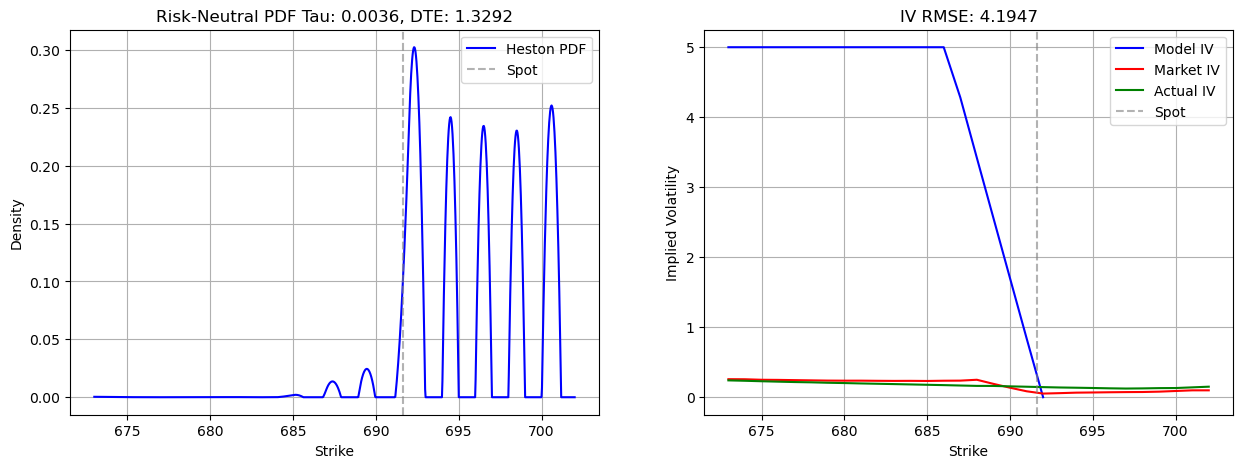

123.94845360320629

In [28]:
from hc2 import calibrate_heston_to_chain, heston_call_price_damped, extract_pdf, vectorized_bs_iv, heston_pdf_via_fft

S0 = stock.price_data.current_price
tau = gcdf['timevalue'].mean()
r = 0.0405
q = 0.00
strikes = gcdf['strike'].values
market_prices = gcdf['lastprice'].values
actual_ivs = gcdf['impliedvolatility'].values

def cb_heston(alpha, N, umax, weight_type, lambd, s, k, S0 = S0, tau = tau, r = r, q = q, strikes = strikes, market_prices = market_prices, actual_ivs = actual_ivs):
    print(f"Calibrating Heston model to chain with alpha: {alpha}, N: {N}, umax: {umax}, weight_type: {weight_type}, lambd: {lambd}, s: {s}, k: {k}")
    # Compute model prices with opt_params
    opt_params, rmse = calibrate_heston_to_chain(strikes, market_prices, S0, tau, r, q, lambd_sv = lambd, alpha = alpha, N = N, umax = umax, weight_type = weight_type)
    # kappa, theta, v0, rho, xi = opt_params
    kappa, theta, v0, rho, xi, lambda_j, mu_j, sigma_j = opt_params

    # model_prices = heston_call_price_damped(S0, strikes, v0, kappa, theta, xi, rho, lambd, tau, r, q=q, alpha = alpha, N = N, umax = umax)
    model_prices = heston_call_price_damped(S0, strikes, v0, kappa, theta, xi, rho, lambd, tau, r, q=q, alpha=alpha, N=N, umax=umax,
                                        lambda_j=lambda_j, mu_j=mu_j, sigma_j=sigma_j)

    # Extract PDF from model prices (or market if preferred)
    strikes_pdf, pdf_values = extract_pdf(strikes, model_prices, r, tau, s = s, k = k)

    ### IV RMSE Check
    model_ivs = vectorized_bs_iv(model_prices, S0, strikes, tau, r, q, is_call=(strikes >= S0))
    market_ivs = vectorized_bs_iv(market_prices, S0, strikes, tau, r, q, is_call=(strikes >= S0))
    iv_rmse = np.sqrt(np.nanmean((model_ivs - market_ivs)**2))
    # Extract Pure Market PDF, without model assumptions.
    market_pdf = extract_pdf(strikes, market_prices, r, tau, s = s, k = k)
    # hpdf = heston_pdf_via_fft(S0 = S0, v0 = v0, kappa = kappa, theta = theta, xi = xi, rho = rho, lambd = lambd, tau = tau, r = r, q = q, N = N, L = 0.025)
    hpdf = heston_pdf_via_fft(S0=S0, v0=v0, kappa=kappa, theta=theta, xi=xi, rho=rho, lambd_sv=lambd, tau=tau, r=r, q=q, N=N, L=0.025,
                            lambda_j=lambda_j, mu_j=mu_j, sigma_j=sigma_j)
    fig, ax = plt.subplots(1,2,figsize=(15, 5))

    ax[0].plot(strikes_pdf, pdf_values, label='Heston PDF', color = 'blue')
    # twiny = ax[0].twiny()
    # twiny.plot(hpdf[0], hpdf[1], label='Heston PDF via FFT', color = 'orange')
    ax[0].set_xlabel('Strike')
    ax[0].set_ylabel('Density')
    ax[0].axvline(S0, color='gray', ls='--', alpha=0.6, label='Spot')
    ax[0].set_title('Risk-Neutral PDF ' +f'Tau: {tau:.4f}, DTE: {tau * 365:.4f}')
    ax[0].grid()
    ax[0].legend()

    ax[1].plot(strikes, model_ivs, label='Model IV', color='blue')
    ax[1].plot(strikes, market_ivs, label='Market IV', color='red')
    ax[1].plot(strikes, actual_ivs, label='Actual IV', color='green')
    ax[1].axvline(S0, color='gray', ls='--', alpha=0.6, label='Spot')
    ax[1].set_xlabel('Strike')
    ax[1].set_ylabel('Implied Volatility')
    ax[1].set_title(f'IV RMSE: {iv_rmse:.4f}')
    ax[1].grid()
    ax[1].legend()
    plt.show()

    return pd.DataFrame({'strikes': strikes, 'real_prices': market_prices, 'model_prices': model_prices, 'ivs': actual_ivs, })



# Calibrate
alpha = .00567
N = 2048
umax = 1000
weight_type = 'otm'
lambd = 0.0
s = 0.05
k = 4

check = cb_heston(alpha, N, umax, weight_type, lambd, s, k)
def rmse(x, y):
    return np.sqrt(np.nanmean((x - y)**2))

rmse(check['real_prices'], check['model_prices'])


In [24]:
from ipywidgets import interact

def interactive_cb_heston():
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    # Define widget controls for cb_heston parameters
    alpha_slider = widgets.FloatSlider(
        value=0.001, min=0.0001, max=.50, step=0.05,
        description='alpha', continuous_update=False)
    N_slider = widgets.IntSlider(
        value=1024, min=50, max=5000, step=10,
        description='N', continuous_update=False)
    umax_slider = widgets.IntSlider(
        value=500, min=100, max=2500, step=50,
        description='umax', continuous_update=False)
    lambd_slider = widgets.FloatSlider(
        value=0.0, min=-0.5, max=1.0, step=0.01,
        description='lambda', continuous_update=False)
    s_slider = widgets.FloatSlider(
        value=0.05, min=0.001, max=0.1, step=0.001,
        description='s', continuous_update=False)
    k_slider = widgets.IntSlider(
        value=4, min=1, max=10, step=1, description='k', continuous_update=False)
    weight_type_dropdown = widgets.Dropdown(
        options=['otm', 'atm', 'none'], value='otm', description='weight')

    def update_interactive(alpha, N, umax, weight_type, lambd, s, k):
        clear_output(wait=False)
        plt.close('all')  # avoid stacking figures so only one plot shows
        # get_heston_pdf returns (strikes_pdf, pdf_values); cb_heston only plots and returns None
        strikes, pdf, rmse = get_heston_pdf(alpha, N, umax, weight_type, lambd, s, k)
        plt.figure(figsize=(8, 4))
        plt.plot(strikes, pdf, color='navy', lw=2, label='Heston PDF')
        plt.xlabel('Strike')
        plt.ylabel('PDF')
        plt.title(
            f'Heston PDF | α={alpha:.3f}, N={N}, umax={umax}, λ={lambd:.2f}, s={s:.3f}, k={k}, weight={weight_type} | RMSE: {rmse}')
        plt.legend()
        plt.tight_layout()
        plt.show()

    interact(update_interactive,
             alpha=alpha_slider,
             N=N_slider,
             umax=umax_slider,
             weight_type=weight_type_dropdown,
             lambd=lambd_slider,
             s=s_slider,
             k=k_slider)


# Usage example:
interactive_cb_heston()

interactive(children=(FloatSlider(value=0.001, continuous_update=False, description='alpha', max=0.5, min=0.00…

In [10]:
S0 * np.exp((r-q)*tau)

687.4652081057484

In [14]:
import numba